# RQ1 Visual Report

Generate and preview the fast, report-focused RQ1 visualizations from run artifacts.

This notebook wraps `src.make_figures` and then displays the generated PNG figures inline.

In [21]:
from pathlib import Path

# Repo root: notebook is in notebooks/
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

# Set this to your target run id
RUN_ID = "rq1_full_pipeline-20260503-083026"

# Optional overrides for the current make_figures CLI
DPI = 180
OUTPUT_DIR = REPO_ROOT / "results" / "runs" / RUN_ID / "figures" / "rq1_report"

print("REPO_ROOT:", REPO_ROOT)
print("RUN_ID:", RUN_ID)
print("OUTPUT_DIR:", OUTPUT_DIR)

REPO_ROOT: /Users/gattimartina/Documents/EPFL/Master/MA4/CS-503-Visual-Intelligence/one-trunk-or-many
RUN_ID: rq1_full_pipeline-20260503-083026
OUTPUT_DIR: /Users/gattimartina/Documents/EPFL/Master/MA4/CS-503-Visual-Intelligence/one-trunk-or-many/results/runs/rq1_full_pipeline-20260503-083026/figures/rq1_report


In [22]:
import subprocess
import sys

cmd = [
    sys.executable,
    "-m",
    "src.make_figures",
    "--run-id",
    RUN_ID,
    "--output-dir",
    str(OUTPUT_DIR),
    "--dpi",
    str(DPI),
]

res = subprocess.run(cmd, cwd=REPO_ROOT, capture_output=True, text=True)
print(res.stdout)
if res.returncode != 0:
    print(res.stderr)
    raise RuntimeError(f"Figure generation failed (exit={res.returncode})")

Metrics : /Users/gattimartina/Documents/EPFL/Master/MA4/CS-503-Visual-Intelligence/one-trunk-or-many/results/runs/rq1_full_pipeline-20260503-083026/metrics/metrics.csv
Null    : /Users/gattimartina/Documents/EPFL/Master/MA4/CS-503-Visual-Intelligence/one-trunk-or-many/results/runs/null_distributions/rq1_full_pipeline-20260503-083026/null_distribution_19scenes_1000draws.csv
Output  : /Users/gattimartina/Documents/EPFL/Master/MA4/CS-503-Visual-Intelligence/one-trunk-or-many/results/runs/rq1_full_pipeline-20260503-083026/figures/rq1_report

  v  fig01_convergence_ribbon.png
  v  fig02_dot_whisker_null.png
  v  fig03_zscore_bars.png
  v  fig04_metric_scatter.png
  v  fig05_null_violin.png
  v  fig06_convergence_heatmap.png
  v  fig07_above_below_summary.png

Done - 7 figures in /Users/gattimartina/Documents/EPFL/Master/MA4/CS-503-Visual-Intelligence/one-trunk-or-many/results/runs/rq1_full_pipeline-20260503-083026/figures/rq1_report/



## RQ1 — Results (7 figures)

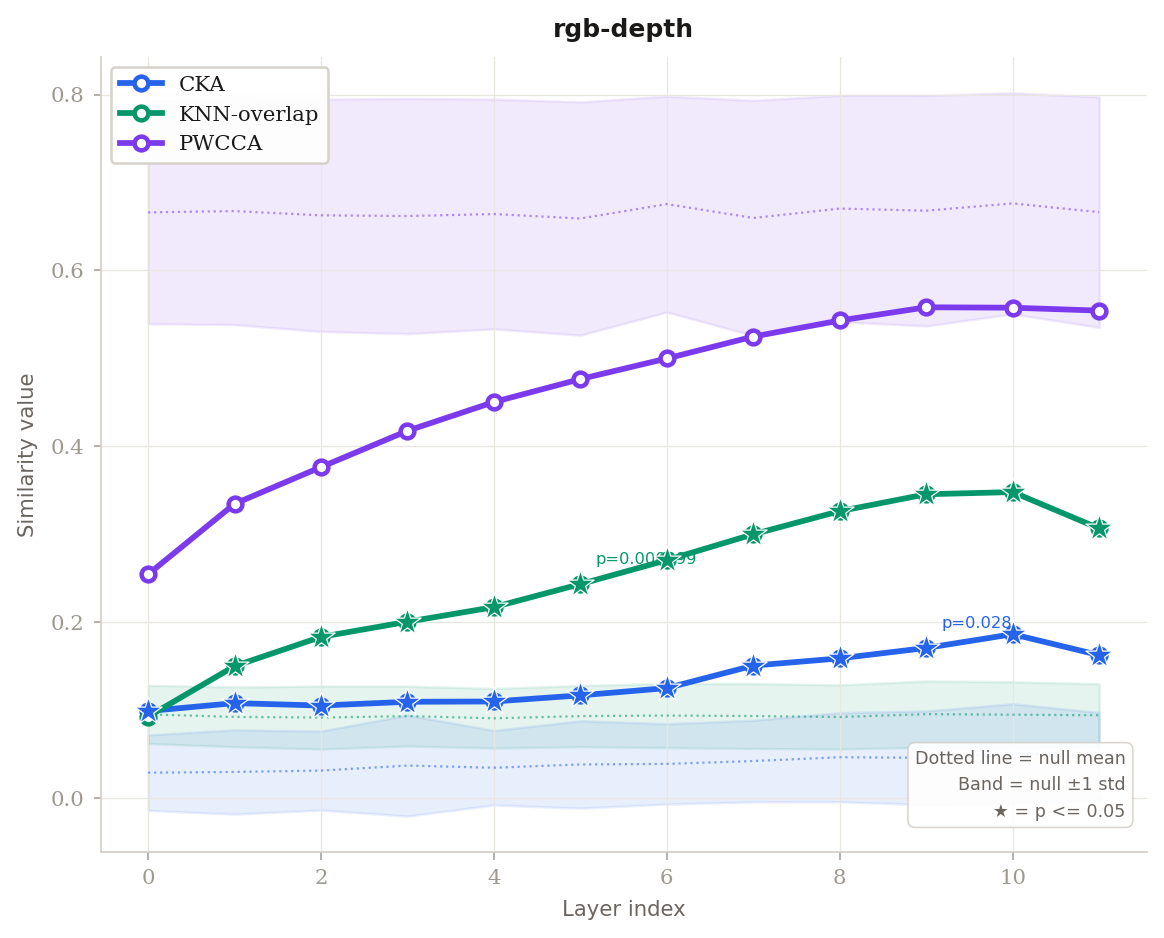

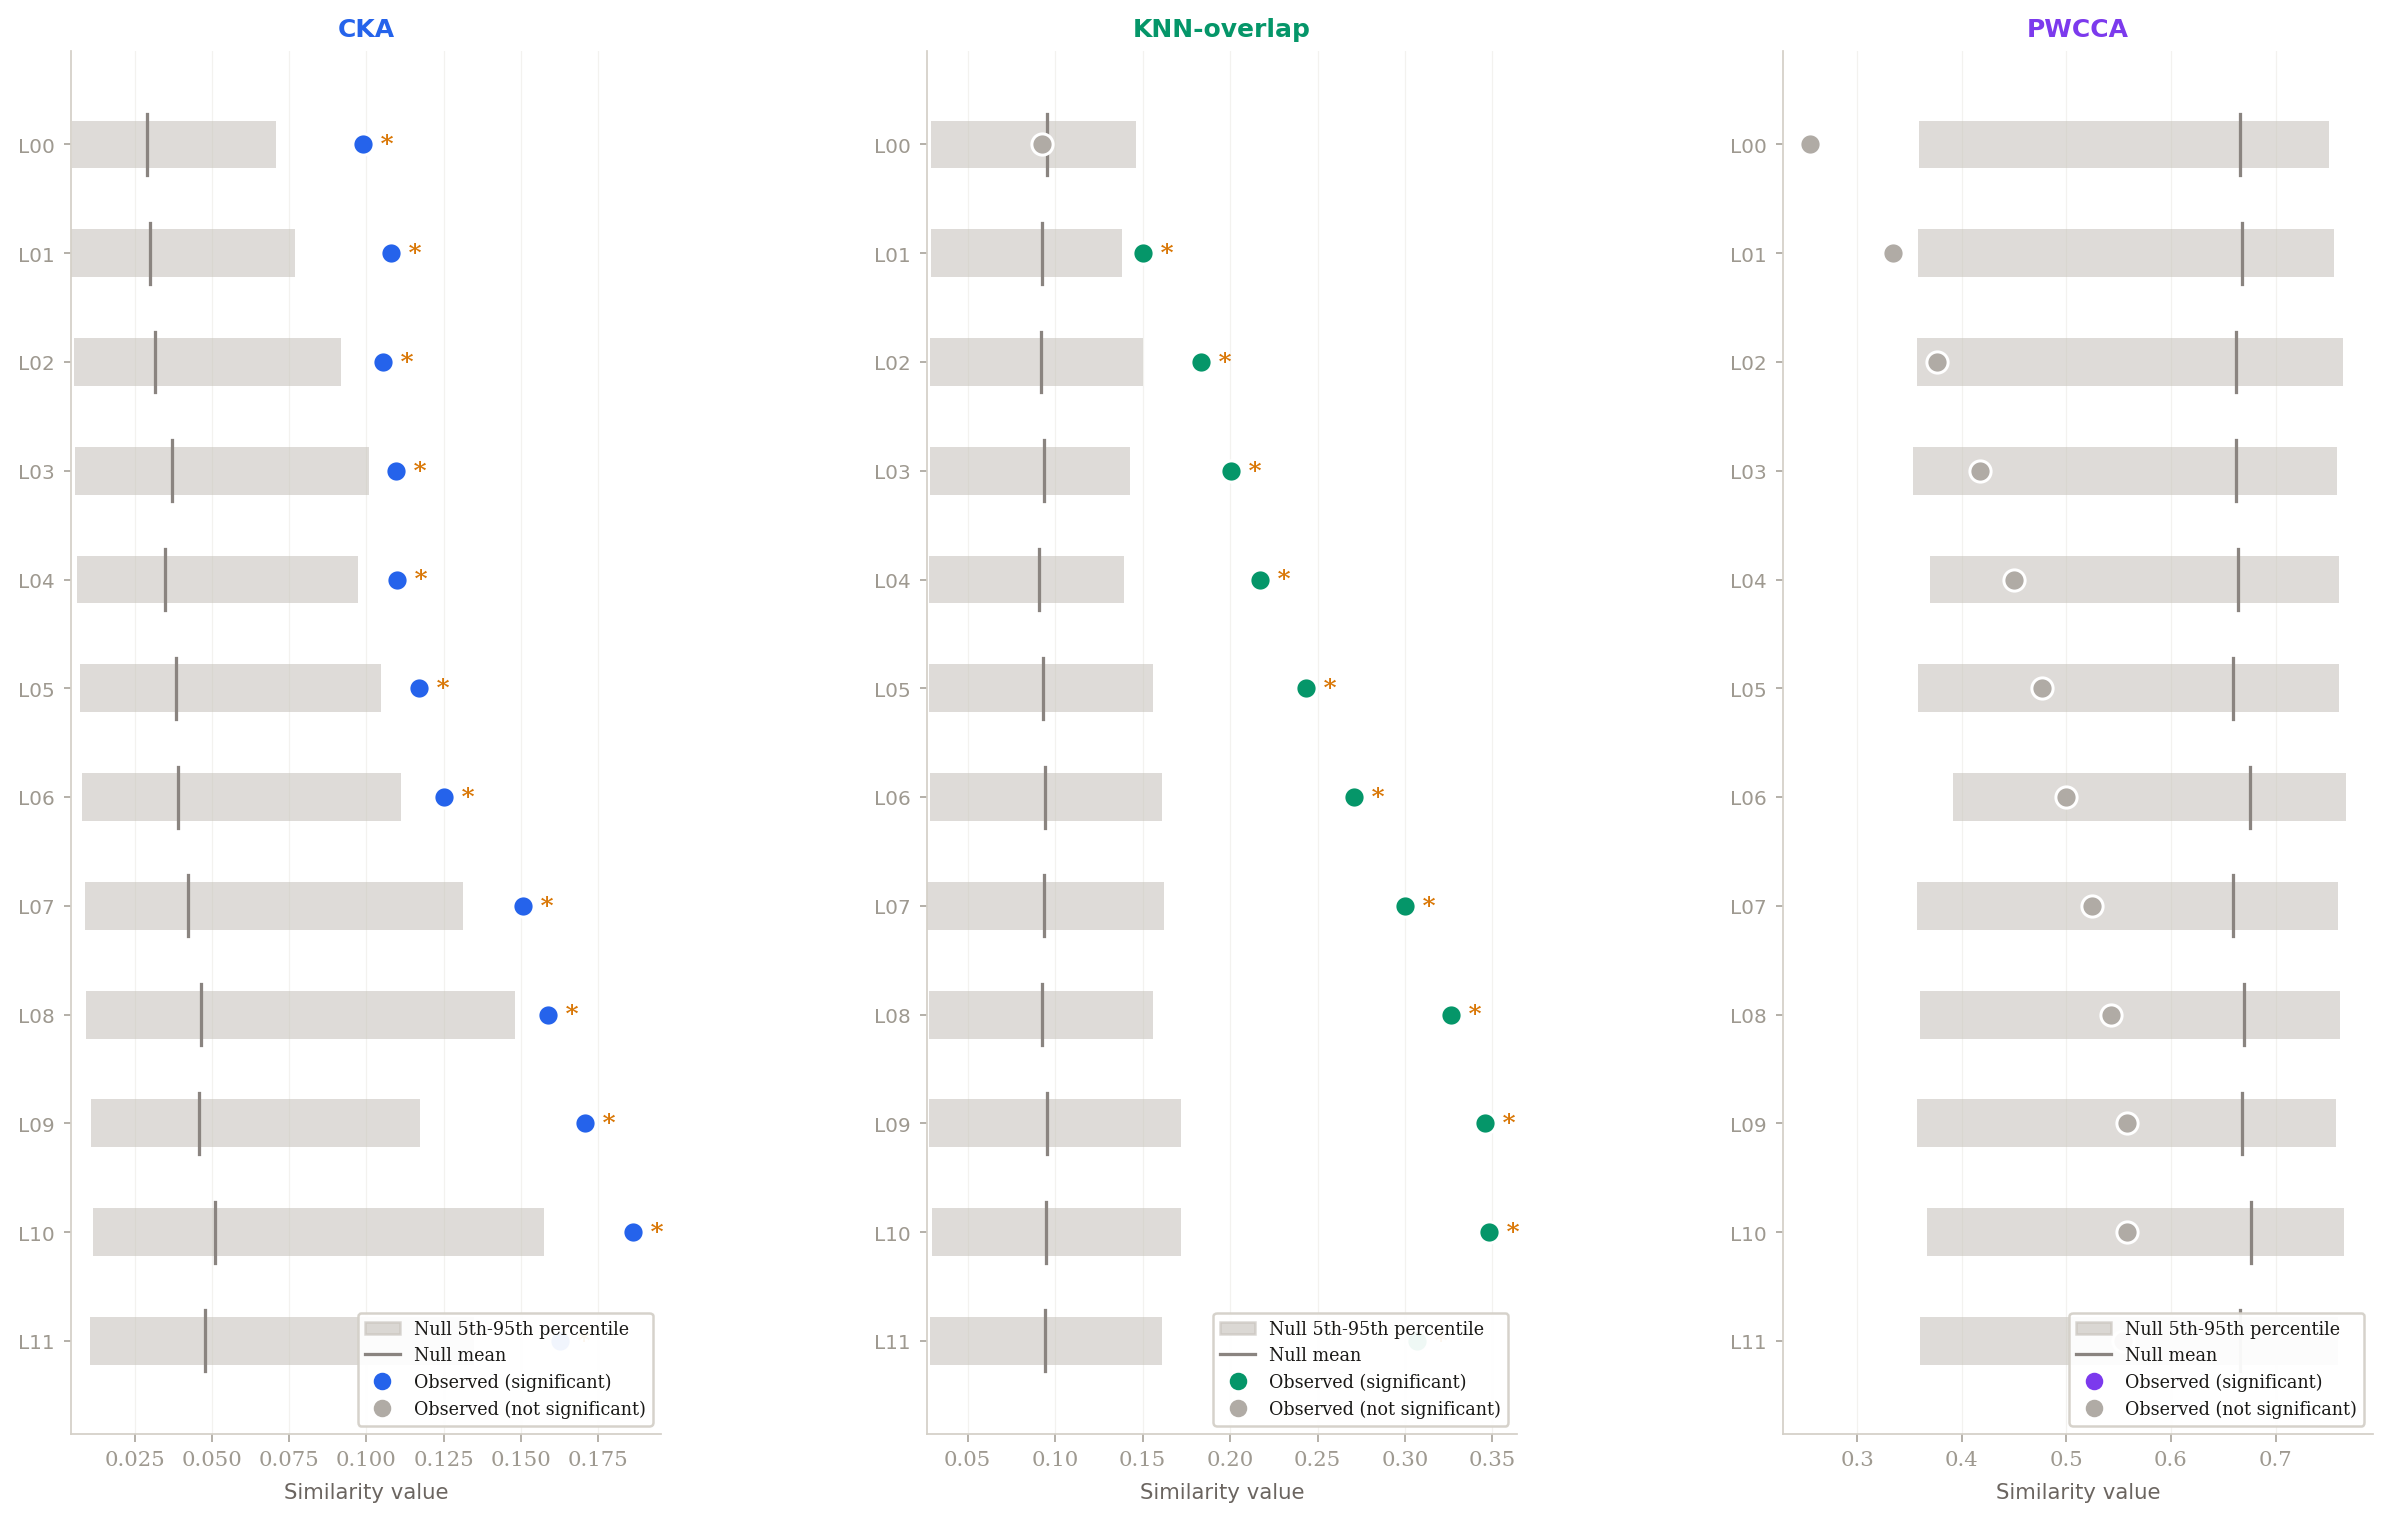

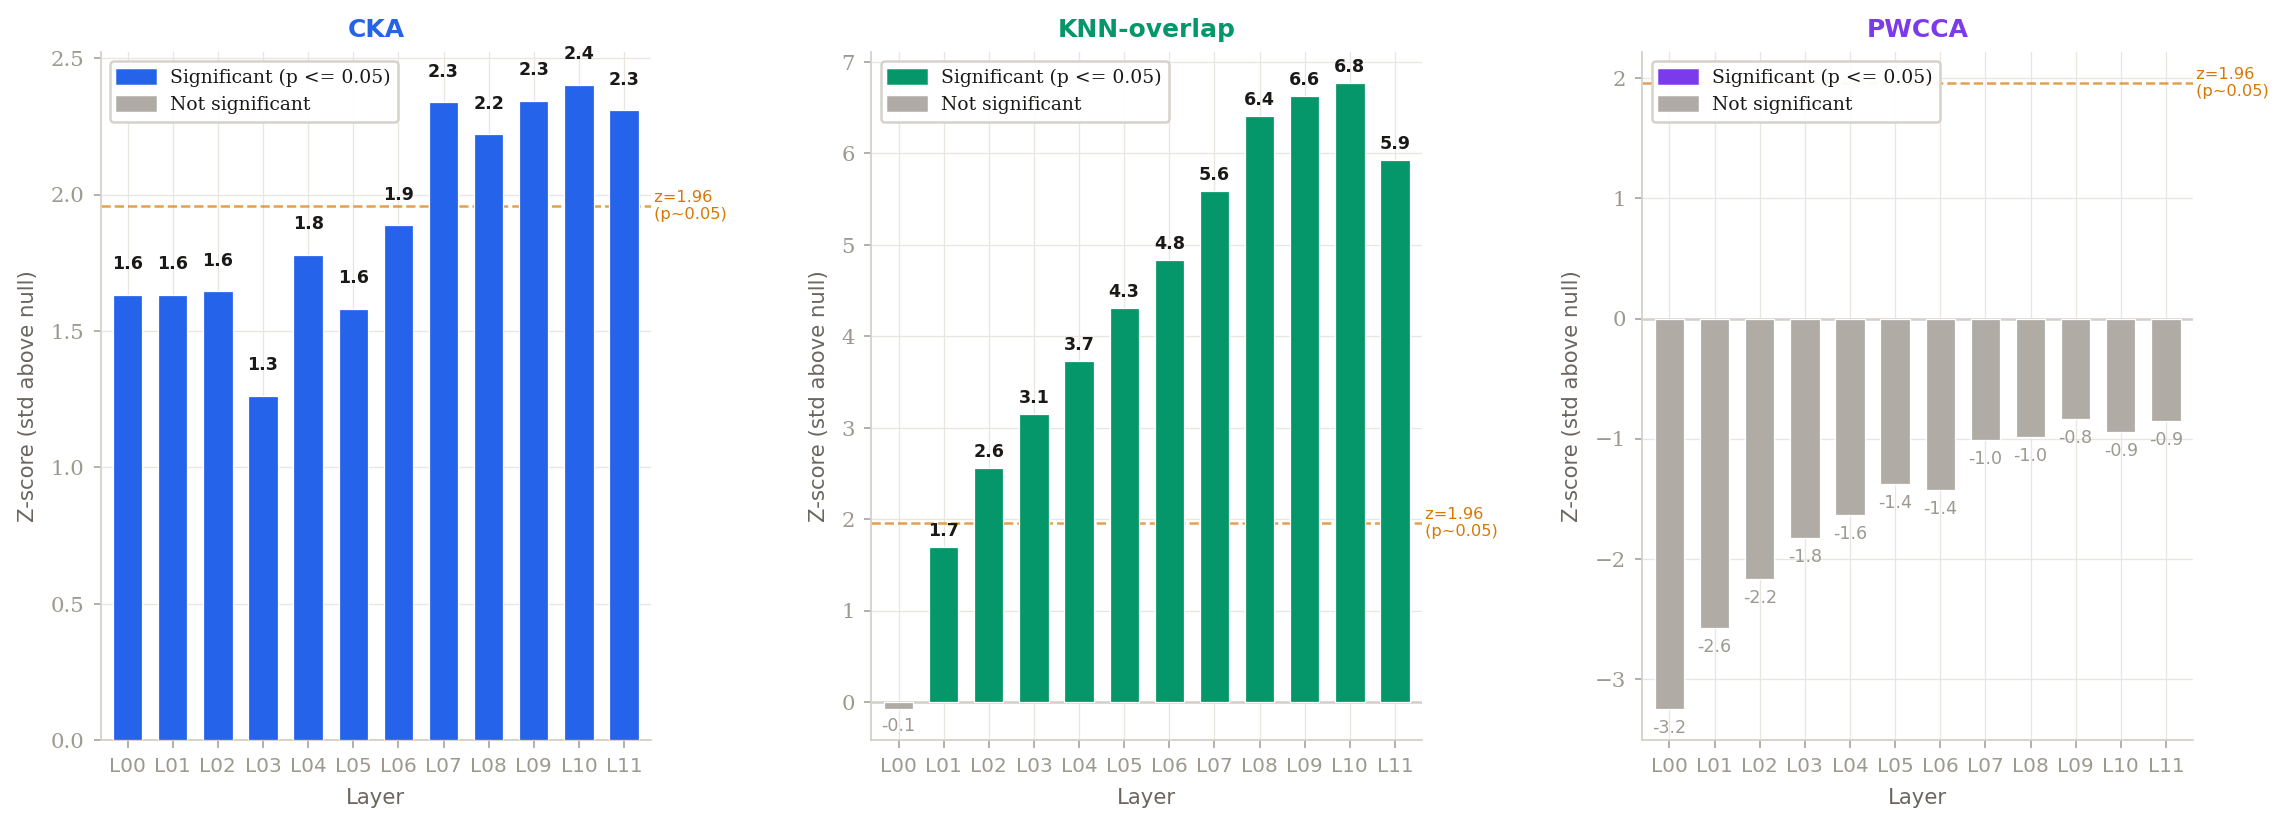

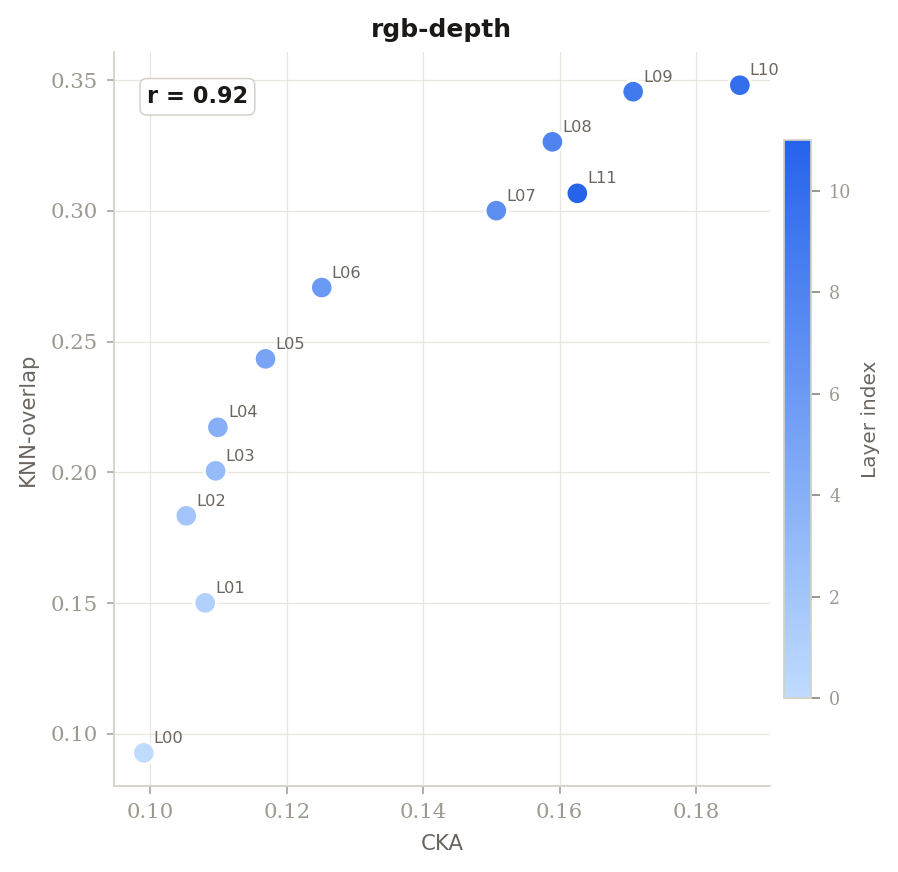

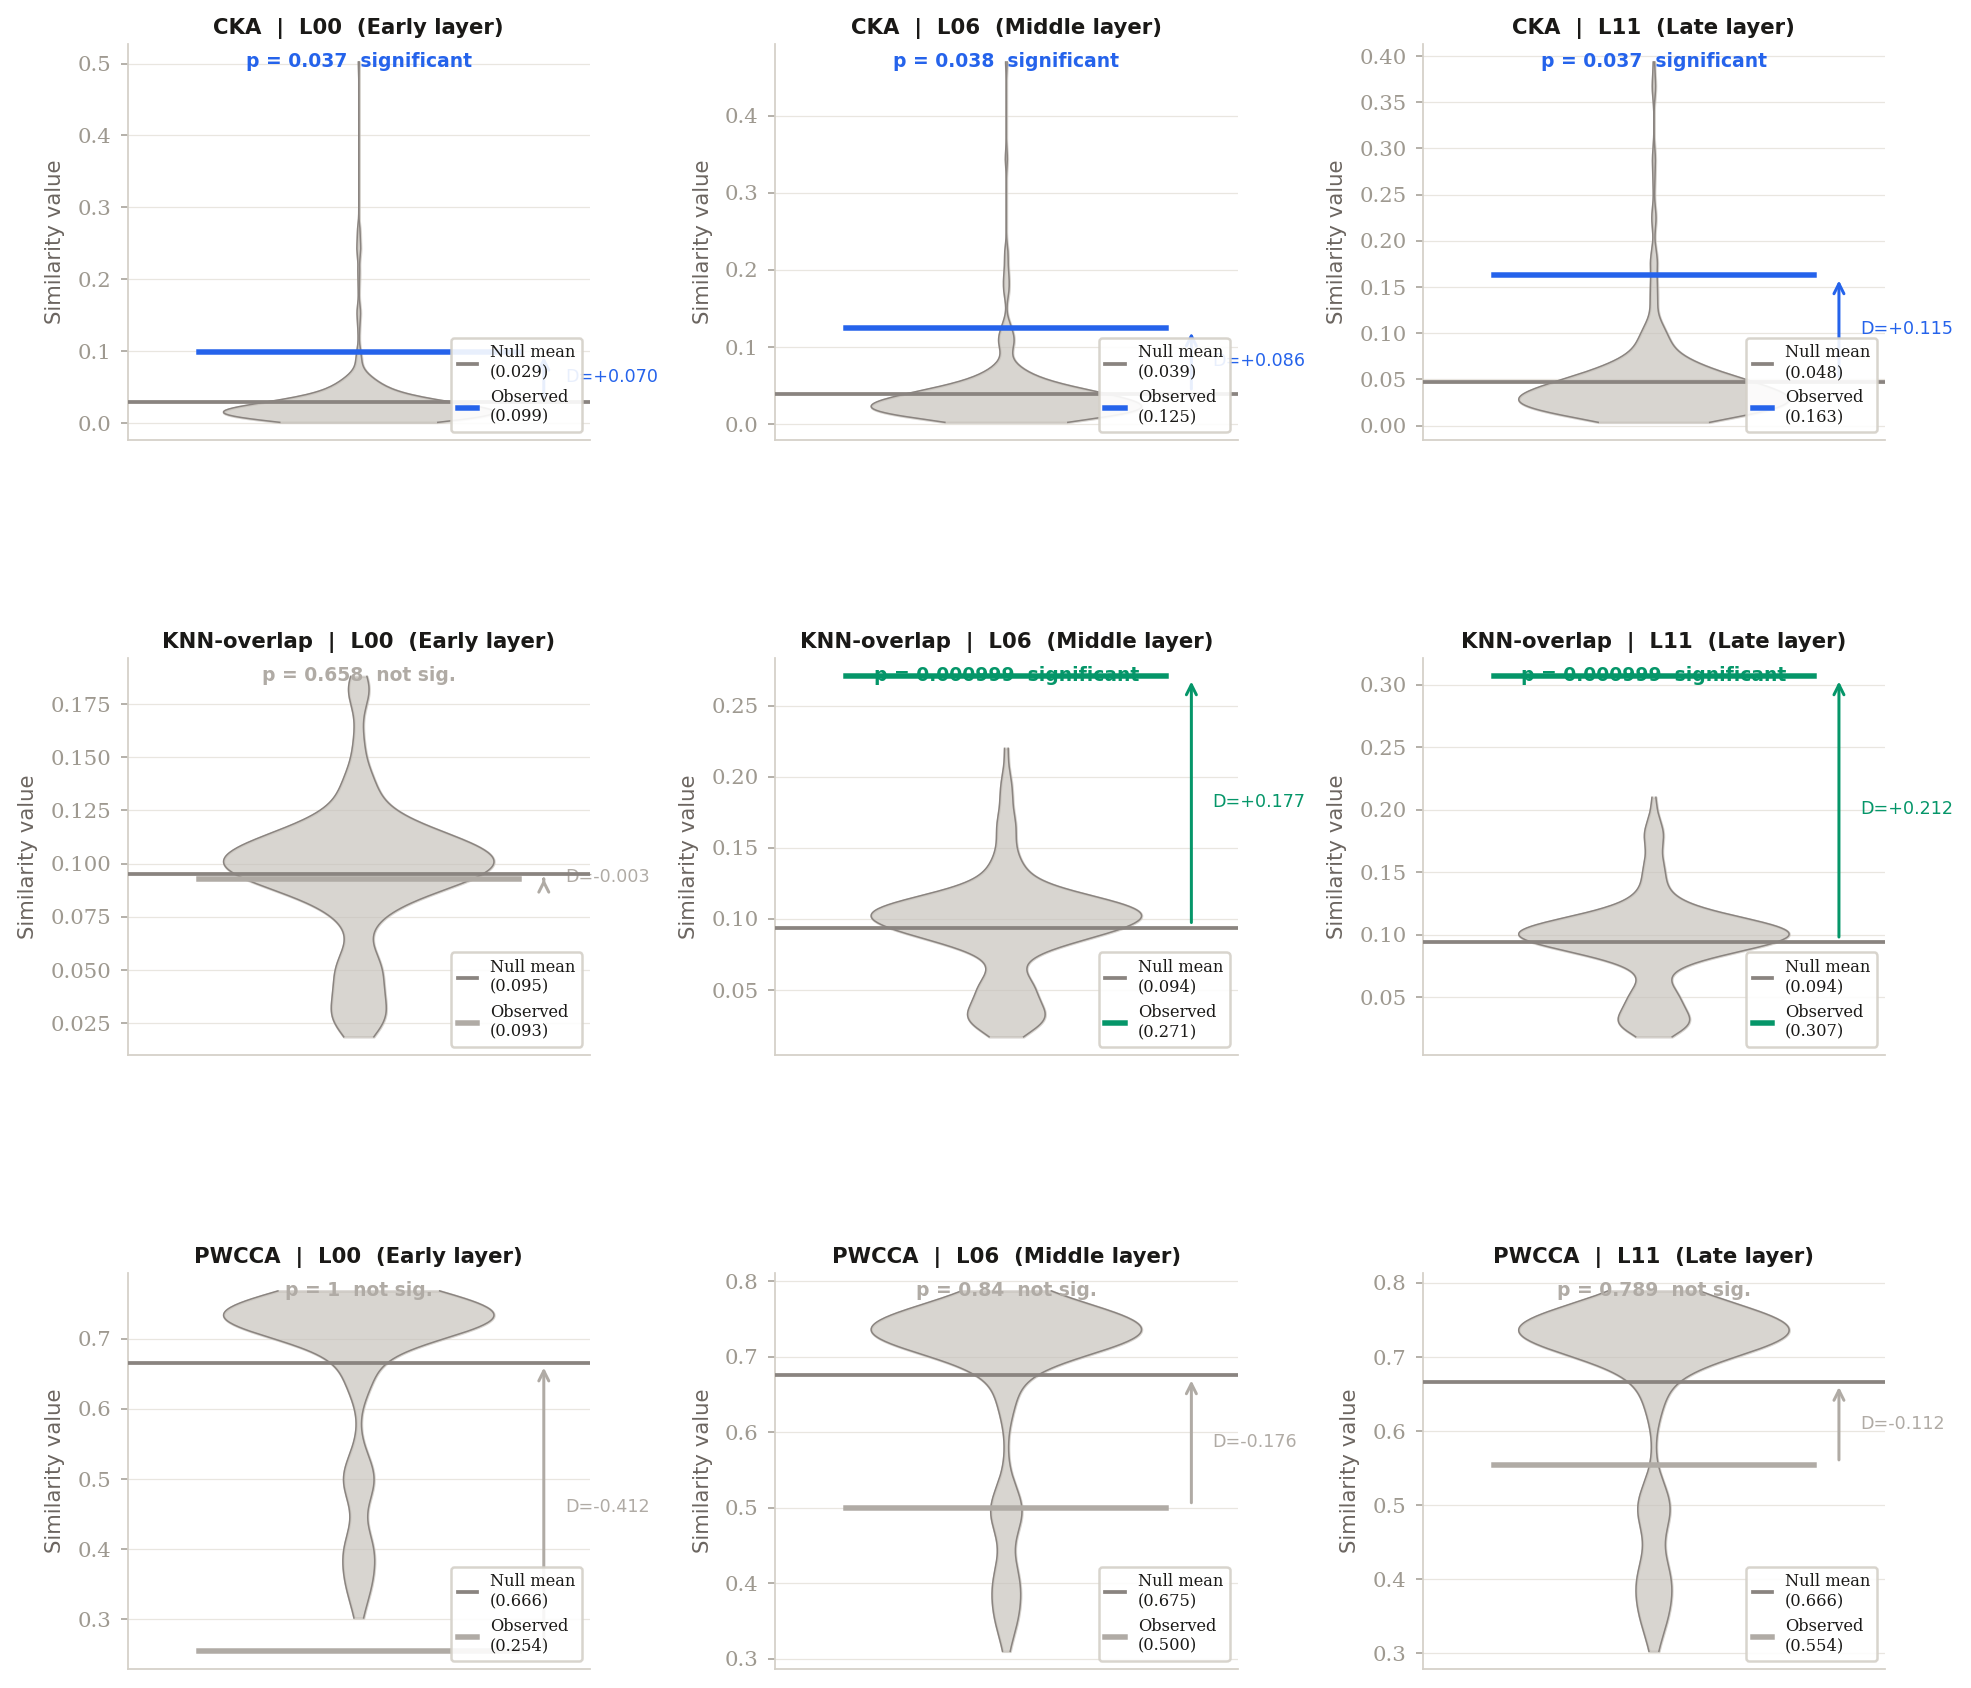

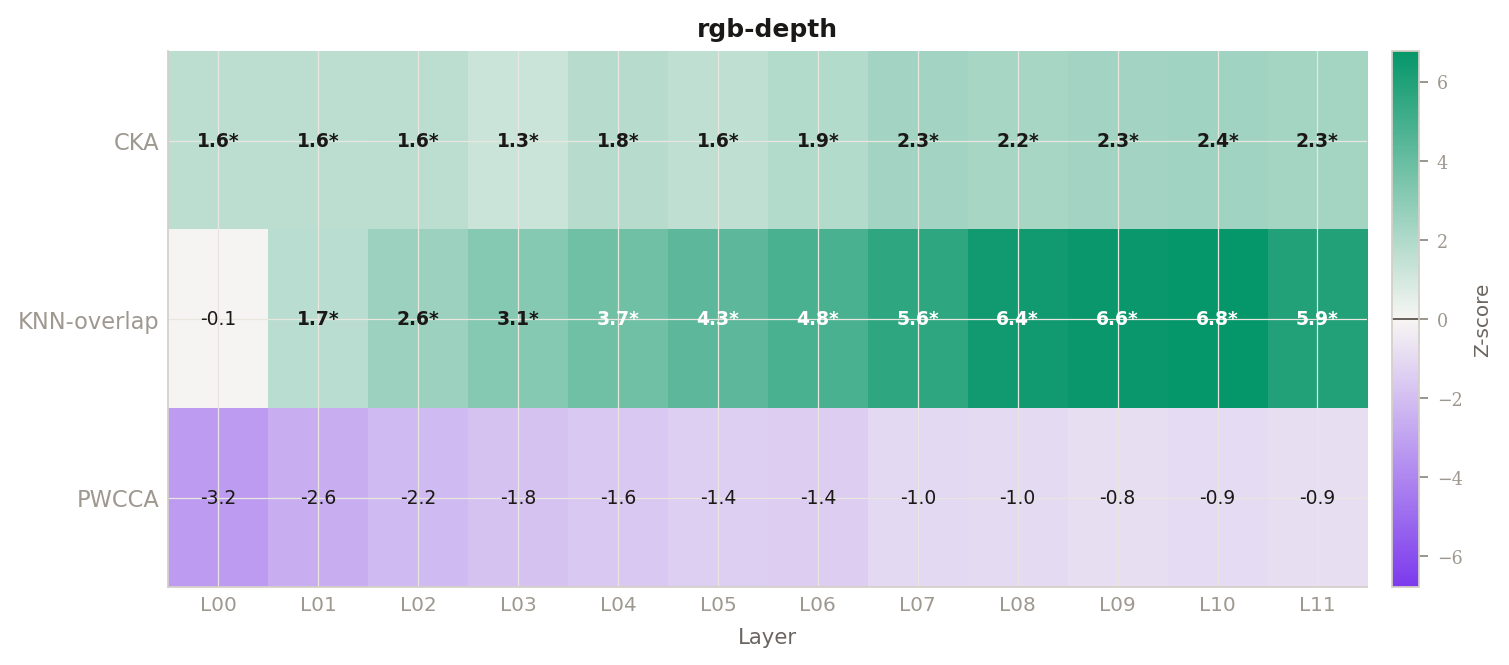

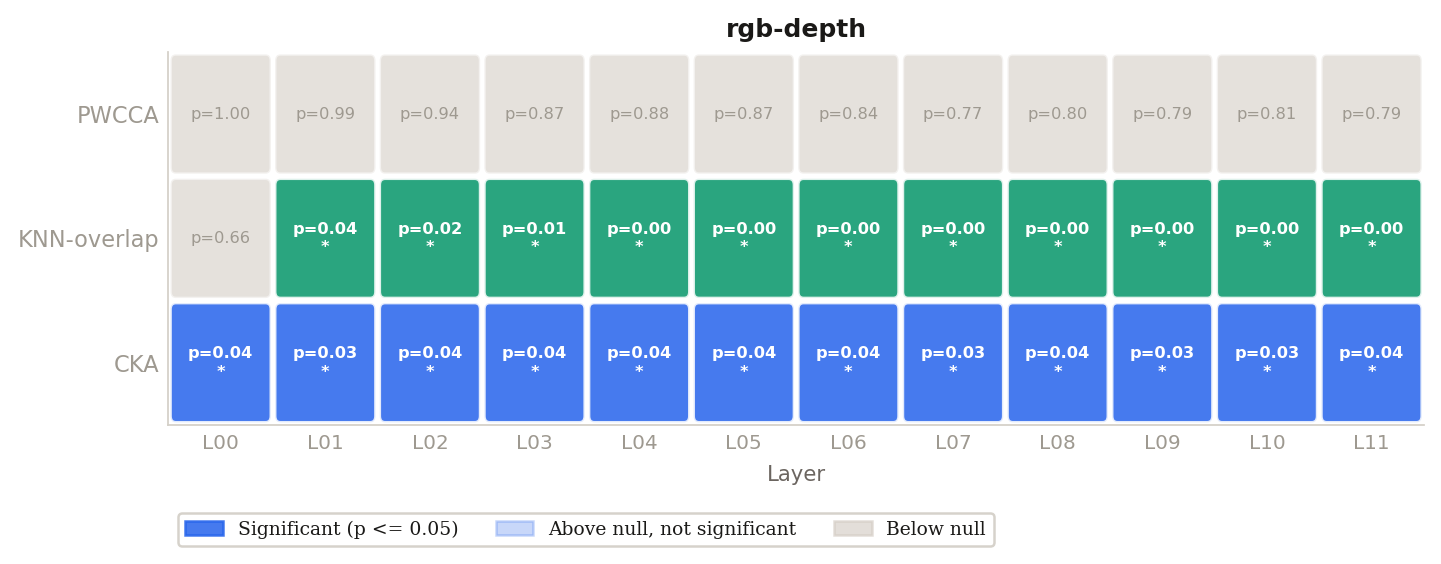

In [23]:
from IPython.display import Image, display, Markdown

if not OUTPUT_DIR.exists():
    raise FileNotFoundError(f"Output directory not found: {OUTPUT_DIR}")

figures = sorted(OUTPUT_DIR.glob("fig*.png"))
if not figures:
    raise FileNotFoundError(f"No figure PNGs found in: {OUTPUT_DIR}")

display(Markdown(f"## RQ1 — Results ({len(figures)} figures)"))
for path in figures:
    display(Image(filename=str(path)))